In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("dataset.csv", parse_dates=["Date"])
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [3]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [5]:
df.columns = df.columns.str.strip()

In [6]:
df.dtypes

OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

In [7]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [8]:
df["CouponCode"].isnull().sum()/len(df) * 100

np.float64(25.75)

In [9]:
df["CouponCode"].mode()

0    FREESHIP
Name: CouponCode, dtype: object

There are 25.75% of null values are present in the couponcode column

This is an categorical column so in this column we fill the null with mode and mode is  FREESHIP.



In [10]:
# For EDA, missing values are filled with "No Coupon" instead of mode
# to avoid bias in analysis, as using mode would artificially inflate one category
df["CouponCode"].fillna("No Coupon", inplace=True)

In [11]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

There are no duplicate found in the data


In [13]:
round(df["Product"].value_counts(normalize=True)*100,2)

Product
Printer    15.08
Tablet     14.92
Chair      14.83
Laptop     14.42
Desk       14.17
Monitor    13.58
Phone      13.00
Name: proportion, dtype: float64

Insights

Product contribution is evenly distributed, with Printer leading at ~15%. No category dominates, indicating a balanced and diversified product mix.

# KPI Analysis

In [14]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [15]:
df["OrderStatus"]

0         Shipped
1         Shipped
2       Cancelled
3        Returned
4       Delivered
          ...    
1195    Cancelled
1196    Cancelled
1197    Delivered
1198    Cancelled
1199     Returned
Name: OrderStatus, Length: 1200, dtype: object

In [16]:
# KPIs

Average_Order_Value = round(df["TotalPrice"].mean(), 2)
Total_Revenue = df["TotalPrice"].sum()
Total_Quantity = df["Quantity"].sum()

Cancellation_rate = round(
    df[df["OrderStatus"] == "Cancelled"].shape[0] / len(df) * 100, 2
)

Return_rate = round(
    df[df["OrderStatus"] == "Returned"].shape[0] / len(df) * 100, 2
)

Top_Product = df["Product"].mode()[0]

Total_orders = df["OrderID"].nunique() 

avg_items_per_cart = round(df["ItemsInCart"].mean(), 2)


# Print nicely
print("📊 KPI SUMMARY")
print("Total Orders:", Total_orders)
print("Total Revenue:", Total_Revenue)
print("Average Order Value:", Average_Order_Value)
print("Total Quantity:", Total_Quantity)
print("Cancellation Rate (%):", Cancellation_rate)
print("Return Rate (%):", Return_rate)
print("Top Product:", Top_Product)
print("Avg Items per Cart:", avg_items_per_cart)


📊 KPI SUMMARY
Total Orders: 1200
Total Revenue: 1264761.96
Average Order Value: 1053.97
Total Quantity: 3535
Cancellation Rate (%): 20.83
Return Rate (%): 20.58
Top Product: Printer
Avg Items per Cart: 5.48


Insights 

Sales are good and customers are spending well, but too many orders are getting cancelled or returned. 

This is a problem that needs to be fixed. On the positive side, products like printers are popular and customers usually buy multiple items.

#  Outliers Analysis 

In [17]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [18]:
import plotly.express as px

cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

# Convert to long format
df_melted = df[cols].melt(var_name="Feature", value_name="Value")

# Plot
fig = px.box(
    df_melted,
    x="Feature",
    y="Value",
    color="Feature",
    title="📊 Distribution of Numerical Features",
    points="outliers"   # show outliers
)

# Styling (Dark + Premium)
fig.update_layout(
    template="plotly_dark",
    title_x=0.5,
    height=500,
    width=900,
    showlegend=False
)

fig.show()

Insights 

By this visualization I found that there are several outliers present in the Total Price column


In [19]:
q1 = df["TotalPrice"].quantile(0.25)
q3 = df["TotalPrice"].quantile(0.75)

Iqr = q3 - q1

lower = q1-1.5*Iqr
upper = q3+1.5*Iqr

outliers = df[(df["TotalPrice"] < lower) |   (df["TotalPrice"] > upper)]

print("Lower Bound:", lower)
print("Upper Bound:", upper)
print("Outliers:", len(outliers))


Lower Bound: -1341.4125
Upper Bound: 3330.4075
Outliers: 8


In [20]:
print("Outlier %:", round(len(outliers)/len(df)*100, 2), "%")

Outlier %: 0.67 %


The dataset shows minimal outlier presence, and all detected outliers are high-value transactions. This suggests the presence of premium or bulk purchases, which are crucial for business insights. Therefore, these outliers should be retained rather than removed, as they represent valuable revenue-generating behavior.

In [21]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [22]:
df_corr = df[["Quantity","UnitPrice","ItemsInCart","TotalPrice"]].corr()

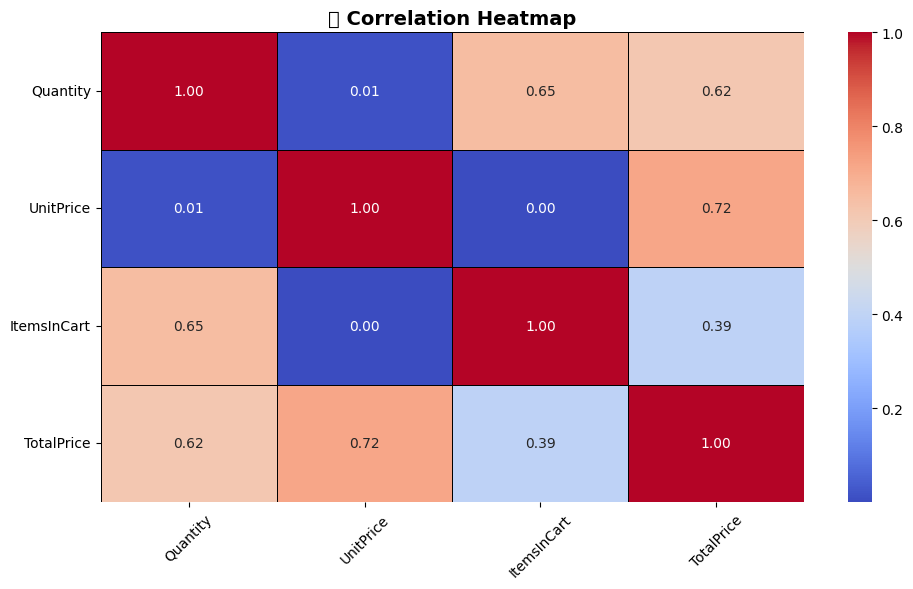

In [23]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_corr,
    annot=True,          
    cmap="coolwarm",    
    fmt=".2f",          
    linewidths=0.5,     
    linecolor="black",
    cbar=True
)

plt.title("📊 Correlation Heatmap", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Insights 

Total revenue is mainly driven by both unit price and quantity, with unit price having a slightly stronger impact. 

Customers often purchase multiple items, and their buying quantity doesn’t seem to change much with price, suggesting fairly stable demand.

# Trend Analysis

In [24]:
import plotly.express as px

# Set index
df = df.set_index("Date")

# Monthly aggregation
df_monthly = df["TotalPrice"].resample("M").sum().reset_index()

# Plot
fig = px.line(
    df_monthly,
    x="Date",
    y="TotalPrice",
    markers=True,
    title="📈 Monthly Sales Trend"
)

# Styling (Dark + Premium)
fig.update_layout(
    template="plotly_dark",
    title_x=0.5,
    height=500,
    width=900,
    xaxis_title="Month",
    yaxis_title="Sales",
)

# Thicker line + glowing markers
fig.update_traces(
    line=dict(width=4, color="#00E5FF"),
    marker=dict(size=8, color="#FF6EC7")
)

fig.show()

Insights 

The sales trend starts from January 2023, with a peak observed around mid-2023. After that, the trend remains relatively stable with some fluctuations. In mid-2024, there is a noticeable drop in sales followed by a sharp increase in June 2024. Post that period, the sales trend stabilizes again with moderate variations.


These fluctuations may be influenced by seasonal demand, promotions, or external factors.

# Cancellation and Return Analysis

In [25]:
df.columns

Index(['OrderID', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [26]:
cancelled = df[df["OrderStatus"]=="Cancelled"]
Returned = df[df["OrderStatus"]=="Returned"]

In [27]:
cancelled["ReferralSource"].value_counts()

ReferralSource
Email        59
Google       58
Referral     50
Facebook     42
Instagram    41
Name: count, dtype: int64

In [28]:
Returned["ReferralSource"].value_counts()

ReferralSource
Facebook     56
Instagram    55
Email        49
Referral     44
Google       43
Name: count, dtype: int64

Insights 

No significant variation is observed across referral sources, indicating it is not a major factor influencing cancellations or returns.

In [29]:
cancelled["CouponCode"].value_counts()

CouponCode
FREESHIP     67
WINTER15     67
No Coupon    58
SAVE10       58
Name: count, dtype: int64

In [30]:
(cancelled["CouponCode"].value_counts() / df["CouponCode"].value_counts()) * 100

CouponCode
FREESHIP     21.405751
No Coupon    18.770227
SAVE10       20.279720
WINTER15     22.945205
Name: count, dtype: float64

Insights

Customers using discounts cancel more orders, especially those using WINTER15. Customers without coupons cancel the least, which shows they are more serious buyers. Also, cancellations are not linked to any specific product.

In [31]:
Returned["CouponCode"].value_counts()

CouponCode
No Coupon    76
WINTER15     63
FREESHIP     61
SAVE10       47
Name: count, dtype: int64

In [32]:
(Returned["CouponCode"].value_counts() / df["CouponCode"].value_counts()) * 100

CouponCode
FREESHIP     19.488818
No Coupon    24.595469
SAVE10       16.433566
WINTER15     21.575342
Name: count, dtype: float64

Insight:

Customers without coupons return the most orders, but discount users also return a significant number of products. This shows that returns are not only caused by discounts but also by product-related issues.

In [33]:
cancelled["Product"].value_counts() 

Product
Chair      45
Monitor    35
Printer    35
Laptop     35
Desk       35
Tablet     34
Phone      31
Name: count, dtype: int64

Insights 

Chair has slightly higher cancellations compared to other products, while phone has the lowest. However, overall cancellations are fairly evenly distributed across products, which suggests that cancellations are not caused by any specific product.

In [34]:
Returned["Product"].value_counts()

Product
Tablet     43
Laptop     39
Printer    38
Monitor    36
Desk       32
Phone      31
Chair      28
Name: count, dtype: int64

Insights 

Most returns are coming from electronic products like tablets, laptops, and printers. This may indicate issues such as product quality problems, damage during delivery, or mismatch between customer expectations and the actual product.

In [35]:
cancelled["PaymentMethod"].value_counts()

PaymentMethod
Credit Card    54
Online         53
Gift Card      50
Cash           49
Debit Card     44
Name: count, dtype: int64

Insights

Cancellations are spread across all payment methods without a significant difference. This indicates that payment method is not the primary reason for order cancellations.

In [36]:
Returned["PaymentMethod"].value_counts()

PaymentMethod
Cash           57
Gift Card      52
Debit Card     51
Credit Card    49
Online         38
Name: count, dtype: int64

Insights

Returned are spread across all payment methods without a significant difference. This indicates that payment method is not the primary reason for order returns.

In [37]:
cancelled["Quantity"].value_counts()

Quantity
4    56
3    50
1    50
5    49
2    45
Name: count, dtype: int64

Insights 

Cancellation is spread among all quantity without a much difference.

In [38]:
Returned["Quantity"].value_counts()

Quantity
1    63
2    53
3    52
5    41
4    38
Name: count, dtype: int64

Insights 

Returned is spread among all quantity without a much difference.

Final Insights 

Chair has the most cancellations, while Tablet and other electronics have the most returns.

Customers using discounts cancel more, while customers without coupons return more.

This shows cancellations are driven by customer behavior, while returns are mainly due to product issues.

Improving product quality and managing discounts can help reduce both problems.

# Univariate Analysis

In [39]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

cols = ["Product", "PaymentMethod", "OrderStatus", "CouponCode", "ReferralSource"]

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[f"{col}" for col in cols],
    vertical_spacing=0.12
)

row, col_pos = 1, 1

colors = ["#00E5FF", "#FF6EC7", "#FFD700", "#00FF9C", "#FF8C00"]

for i, col in enumerate(cols):
    data = df[col].value_counts().reset_index()
    data.columns = [col, "Count"]

    fig.add_trace(
        go.Bar(
            x=data[col],
            y=data["Count"],
            text=data["Count"],
            textposition="outside",
            marker=dict(color=colors[i]),
            cliponaxis=False   # 👈 FIX for label visibility
        ),
        row=row, col=col_pos
    )
    
    col_pos += 1
    if col_pos > 2:
        col_pos = 1
        row += 1

# Layout styling (DARK THEME)
fig.update_layout(
    height=950,
    width=1200,
    title_text="📊 Categorical Feature Dashboard",
    title_x=0.5,
    template="plotly_dark",
    showlegend=False,
    margin=dict(t=100, b=50),
)

# Rotate labels
fig.update_xaxes(tickangle=30)

# Improve spacing so numbers don’t cut off
fig.update_yaxes(showgrid=True)

fig.show()

Insights 

Customer behavior is well balanced across products, payment methods, and referral sources. However, the relatively high number of cancellations and returns stands out as a major concern, indicating potential issues in customer satisfaction, product expectations, or order fulfillment.

In [40]:
df.columns


Index(['OrderID', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

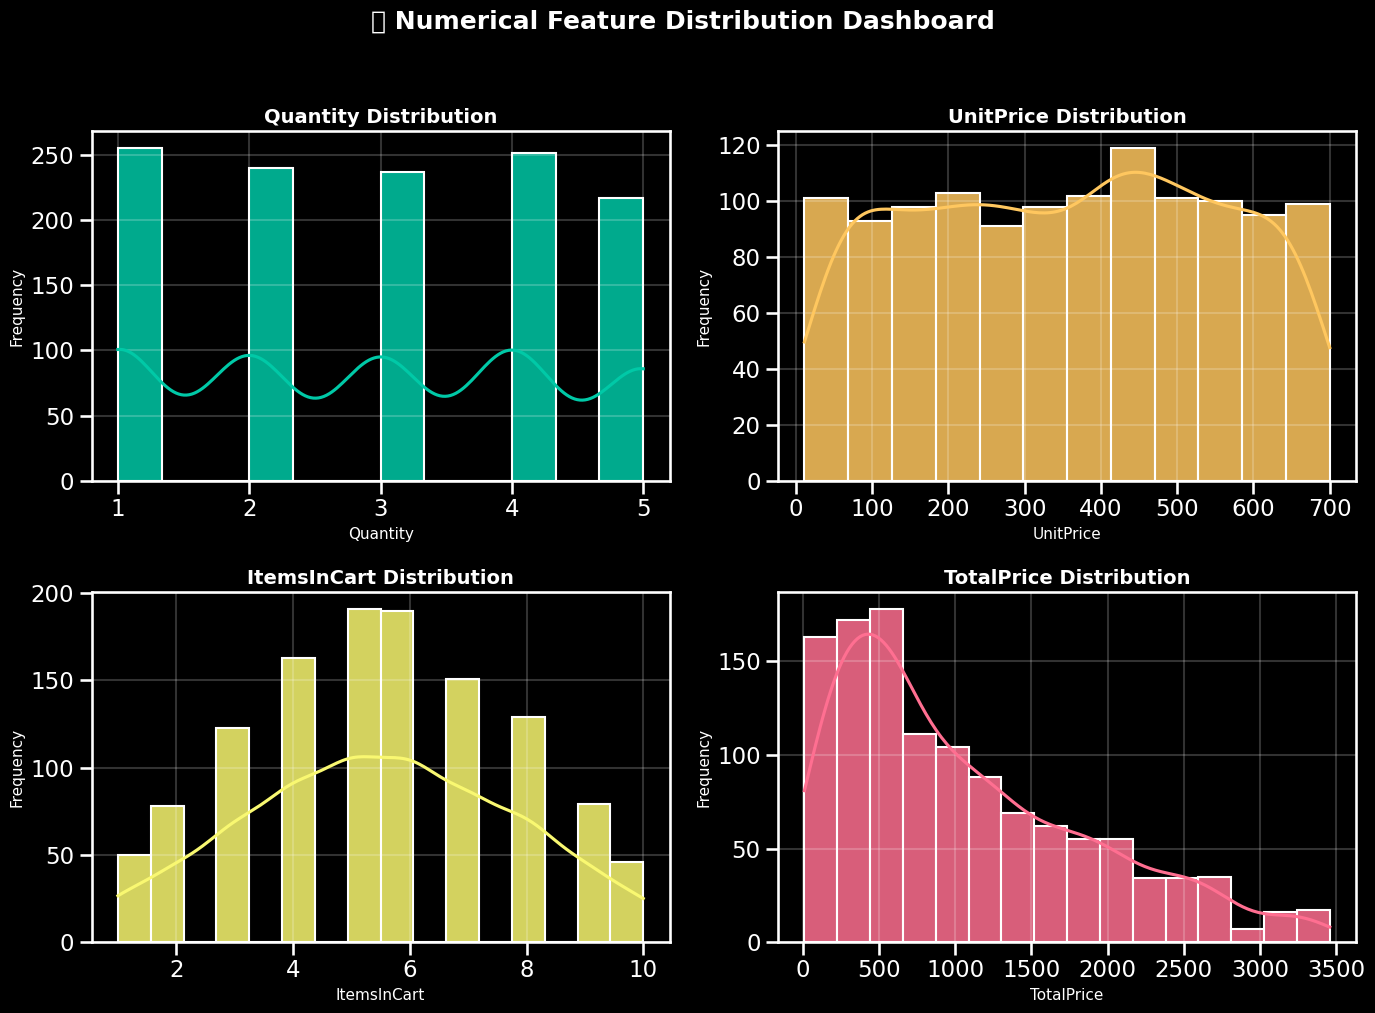

In [41]:
# Premium style
plt.style.use("dark_background")
sns.set_context("talk")

cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
colors = ["#00C9A7", "#FFC75F", "#F9F871", "#FF6F91"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i],
        color=colors[i],
        edgecolor="white",
        alpha=0.85
    )
    
    # Title styling
    axes[i].set_title(
        f"{col} Distribution",
        fontsize=14,
        fontweight="bold",
        color="white"
    )
    
    # Axis labels
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
    
    # Grid styling
    axes[i].grid(alpha=0.2)

# Main title
plt.suptitle(
    "📊 Numerical Feature Distribution Dashboard",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

Insights 

Customers usually purchase between 1–5 items per order. Product prices vary across a wide range, with some items priced significantly higher than others. These higher-priced products lead to a right-skewed distribution in TotalPrice, where most orders are of moderate value but a few high-value orders increase the overall spread.

# Bivariate Analysis

In [42]:
import plotly.express as px

fig = px.box(
    df,
    x="OrderStatus",
    y="TotalPrice",
    color="OrderStatus",   # different colors
    points="all",          # show all data points 🔥
    title="💰 Total Price Distribution by Order Status"
)

fig.update_layout(
    template="plotly_dark",   # dark premium look
    title_x=0.5,
    height=500,
    width=900,
    showlegend=False
)

fig.update_traces(
    marker=dict(size=5, opacity=0.5),
    line=dict(width=2)
)

fig.show()

Insights 

Higher-priced orders are more likely to be cancelled or returned, while lower to mid-range orders are more likely to be successfully delivered. This suggests that price plays an important role in customer decision-making and post-purchase satisfaction.

In [43]:
import plotly.express as px

fig = px.box(
    df,
    x="OrderStatus",
    y="ItemsInCart",
    color="OrderStatus",
    points="all",   # show all points
    title="🛒 Items in Cart Distribution by Order Status"
)

fig.update_layout(
    template="plotly_dark",
    title_x=0.5,
    height=500,
    width=900,
    showlegend=False
)

fig.update_traces(
    marker=dict(size=5, opacity=0.5),
    line=dict(width=2)
)

fig.show()

Insight 

The number of items in the cart does not significantly impact whether an order is cancelled or returned. Customers tend to purchase a similar number of items across all order outcomes.

In [44]:
plt.figure(figsize=(15,8))
px.box(df, x="PaymentMethod", y="TotalPrice", color="OrderStatus")


<Figure size 1500x800 with 0 Axes>

Payment method does not significantly impact order value, but higher-priced transactions, especially through digital methods like credit cards and gift cards, show slightly higher cancellation and return tendencies.

# Final Business Recommendation

The business is generating strong revenue and maintains a healthy Average Order Value, indicating good customer spending behavior. However, high cancellation and return rates remain the biggest challenge, resulting in significant revenue loss. Therefore, the company's primary focus should be on reducing cancellations and returns through better order fulfillment, accurate product information, and improved customer experience.

Special attention should be given to Chairs, which show the highest cancellations, and Tablets and other electronic products, which show the highest returns and revenue loss. These products should be reviewed to identify potential issues related to product expectations, quality, pricing, or delivery.

From a marketing perspective, Instagram is the strongest-performing referral source, while FREESHIP is the highest revenue-generating coupon code. The business should continue leveraging these successful channels and promotional strategies to drive sales.

Since revenue tends to peak during May and June, the company should prepare inventory, marketing campaigns, and operational resources in advance to maximize sales during these high-demand periods.

Overall, the business has strong revenue potential, but improving revenue retention by reducing cancellations and returns will have the greatest impact on profitability and long-term growth.